# Resultados: LLMs contra a baseline SVM

Consolida `llm_slr/results/raw.csv`, dos LLMs, e `baseline_raw.csv`, da SVM legada. Os dois estão
nos mesmos folds temporais e passam pelas mesmas métricas (`llm_slr.eval`).

- WSS@95 (Cohen 2006) é a métrica principal: quanto de leitura se poupa mantendo recall de pelo
  menos 95%.
- best-F1 e ROC-AUC medem a qualidade da ordenação, comparando a escala Likert de 1 a 7 com as
  probabilidades da SVM.
- Célula NaN é combinação ainda não coletada ou fold que não tem as duas classes.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from llm_slr.eval.summary import build_summary, pivot_mean

# cores dos gráficos
C_SURFACE, C_INK, C_MUTED, C_GRID = '#fcfcfb', '#0b0b0b', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.facecolor': C_SURFACE, 'axes.facecolor': C_SURFACE,
    'text.color': C_INK, 'axes.edgecolor': C_MUTED, 'axes.labelcolor': C_MUTED,
    'xtick.color': C_MUTED, 'ytick.color': C_MUTED, 'axes.axisbelow': True,
    'axes.grid': False, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
})

summary = build_summary()
print(f"{len(summary)} linhas (tema × abordagem × fold);",
      f"{summary['approach'].nunique()} abordagens")

240 linhas (tema × abordagem × fold); 10 abordagens


## 1. WSS@95 médio por tema × abordagem

In [2]:
wss = pivot_mean(summary, 'wss95')
wss

theme,games,illiterate,mdwe,ontologies,pair,slr,testing,xbi
approach,,,,,,,,
gemma2:2b/few-shot-random,-0.050,-0.026,0.013,-0.021,0.047,-0.050,-0.022,-0.026
gemma2:2b/few-shot-similar,-0.050,-0.014,-0.050,-0.034,-0.025,-0.050,-0.016,-0.020
gemma2:2b/zero-shot,-0.032,0.308,0.142,0.174,-0.050,0.033,0.516,0.393
llama3.2:3b/few-shot-random,-0.042,0.131,0.057,0.072,-0.022,-0.050,0.069,0.005
llama3.2:3b/few-shot-similar,-0.028,0.070,-0.003,-0.014,0.060,-0.050,0.008,0.029
llama3.2:3b/zero-shot,-0.028,0.486,0.170,0.101,0.136,0.117,0.504,0.465
qwen2.5:3b/few-shot-random,-0.034,-0.012,0.080,-0.032,-0.031,-0.050,0.266,0.406
qwen2.5:3b/few-shot-similar,0.006,0.231,0.166,-0.002,0.006,-0.050,-0.025,-0.030
qwen2.5:3b/zero-shot,-0.008,0.233,0.159,0.176,0.228,0.075,0.585,0.481


## 2. Heatmap de WSS@95

Escala divergente com neutro em 0: azul poupa trabalho de leitura, vermelho é pior que ler tudo
(WSS@95 negativo) e cinza é neutro. O valor vai anotado em cada célula; a cor é só reforço.

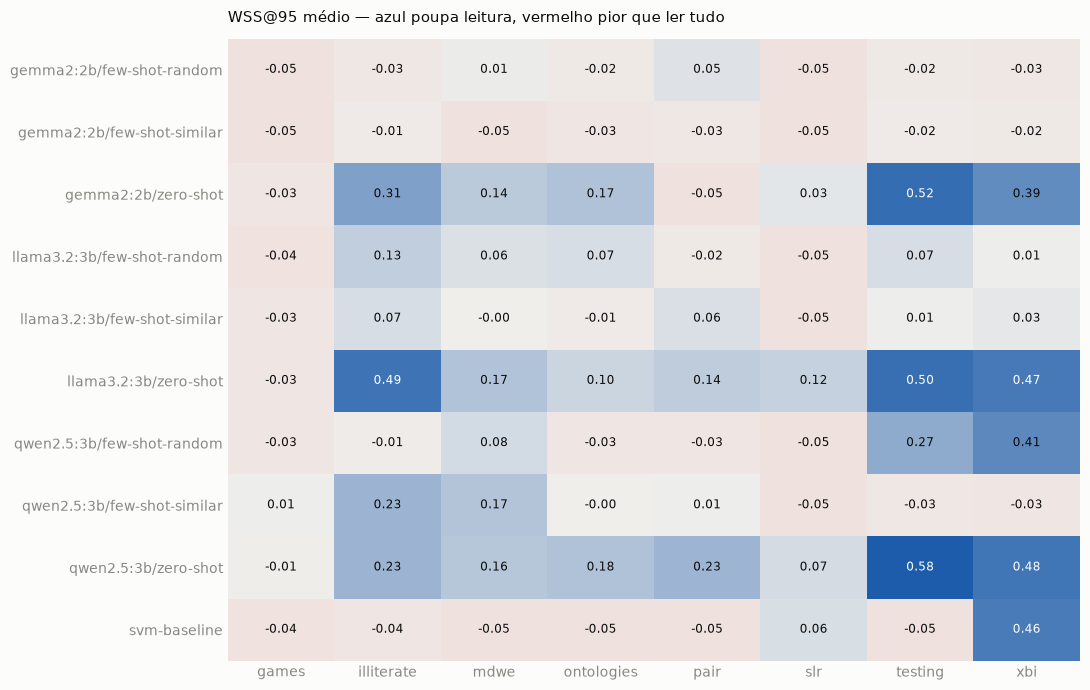

In [3]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def heatmap(pivot, title, fmt='{:.2f}', center=0.0):
    data = pivot.to_numpy(dtype=float)
    # divergente: vermelho, cinza neutro, azul
    cmap = LinearSegmentedColormap.from_list(
        'dv', ['#e34948', '#f0efec', '#1c5cab'])
    cmap.set_bad('#f9f9f7')
    vmax = np.nanmax(np.abs(data - center)) or 1.0
    norm = TwoSlopeNorm(vcenter=center, vmin=center - vmax, vmax=center + vmax)

    fig, ax = plt.subplots(figsize=(11, 0.5 * len(pivot) + 2))
    ax.imshow(np.ma.masked_invalid(data), cmap=cmap, norm=norm, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data[i, j]):
                dist = abs(norm(data[i, j]) - 0.5)
                ax.text(j, i, fmt.format(data[i, j]), ha='center', va='center',
                        fontsize=8.5, color='#ffffff' if dist > 0.35 else C_INK)
    ax.set_title(title, loc='left', fontsize=11, color=C_INK, pad=12)
    ax.spines[:].set_visible(False)
    ax.tick_params(length=0)
    plt.tight_layout()
    plt.show()

heatmap(wss, 'WSS@95 médio — azul poupa leitura, vermelho pior que ler tudo')

## 3. best-F1 e ROC-AUC

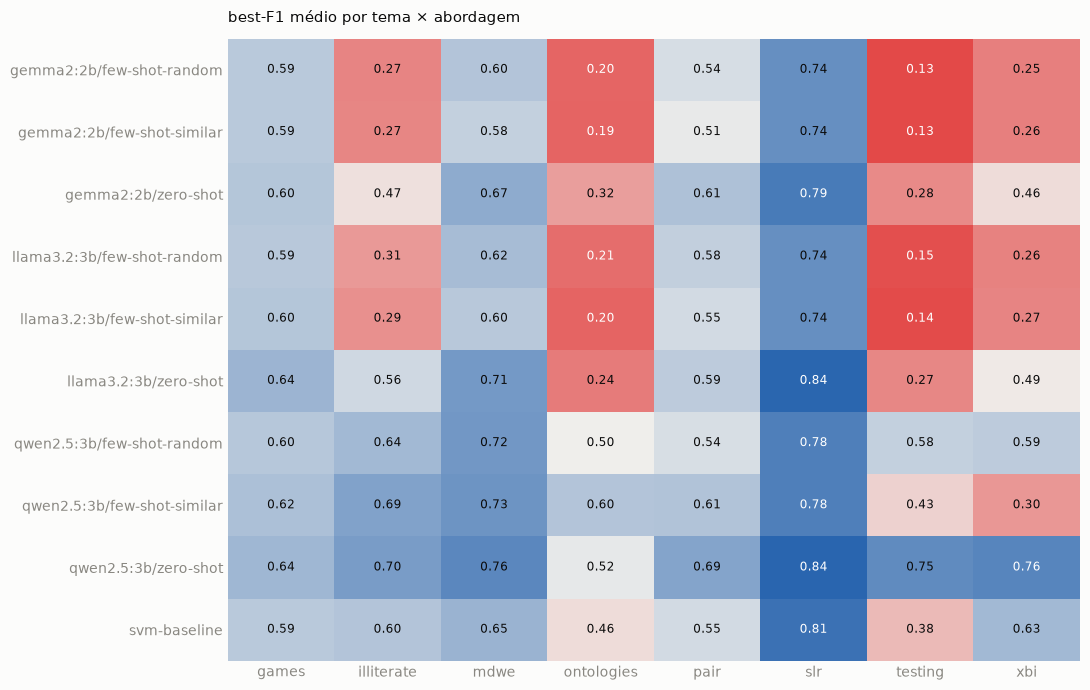

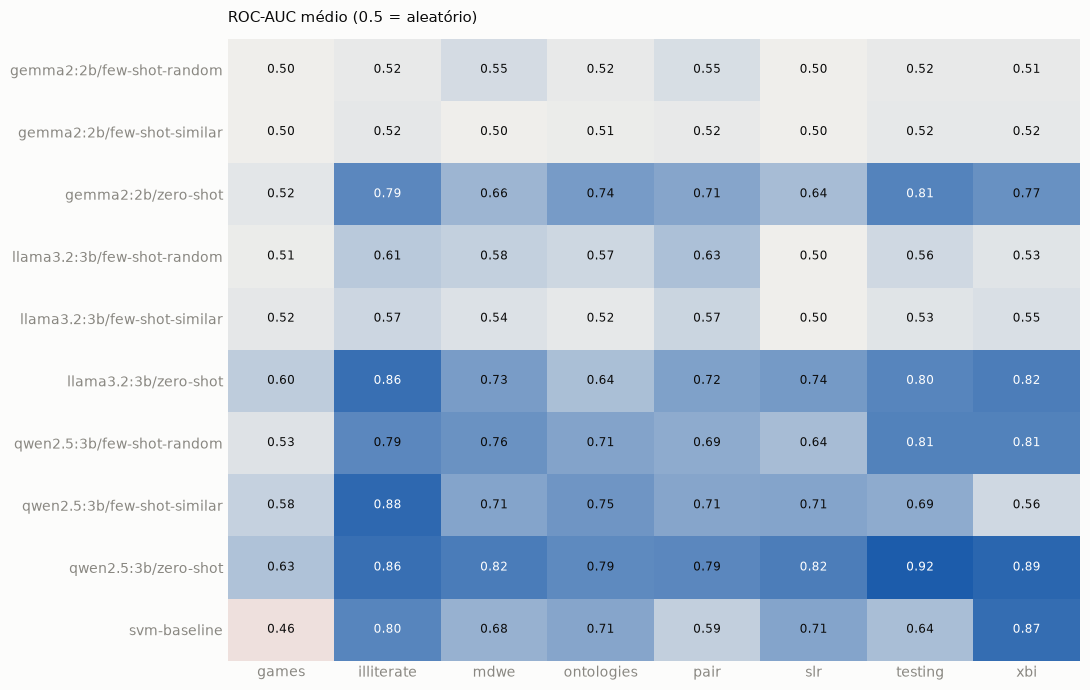

In [4]:
heatmap(pivot_mean(summary, 'best_f1'), 'best-F1 médio por tema × abordagem', center=0.5)
heatmap(pivot_mean(summary, 'roc_auc'), 'ROC-AUC médio (0.5 = aleatório)', center=0.5)

## 4. Diferença de WSS@95 por tema, LLM contra baseline

Valor positivo quer dizer que a abordagem com LLM poupa mais leitura que a SVM no mesmo tema.

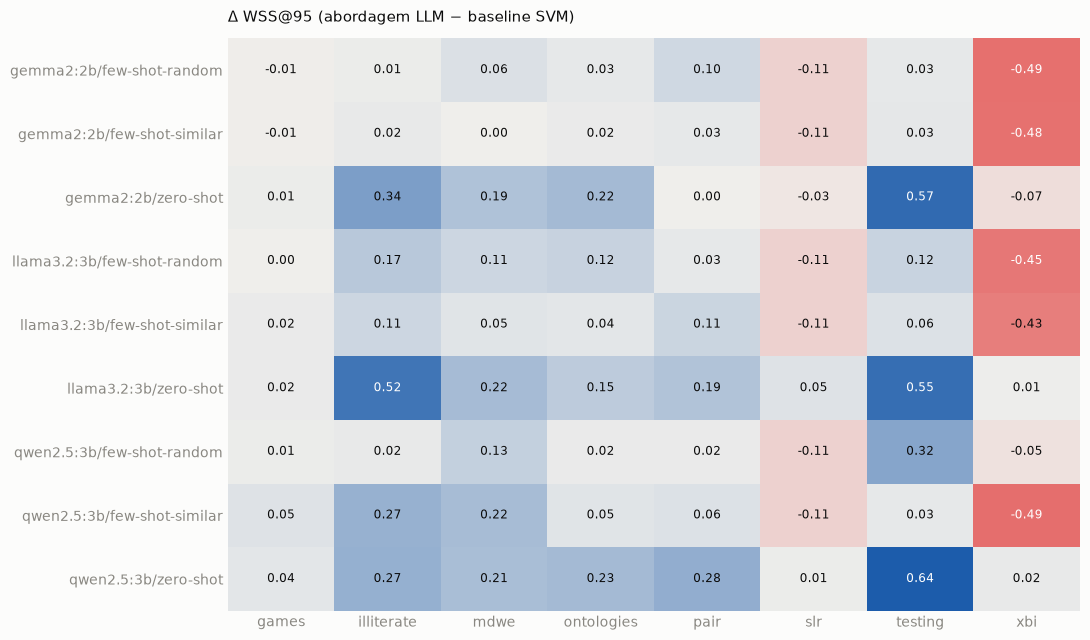

In [5]:
if 'svm-baseline' in wss.index:
    delta = wss.drop(index='svm-baseline') - wss.loc['svm-baseline']
    heatmap(delta, 'Δ WSS@95 (abordagem LLM − baseline SVM)')
else:
    print('baseline ainda não consolidada')

## 5. Latência média de inferência

Serve para avaliar a viabilidade em hardware comum.

In [6]:
llm_rows = summary[summary['approach'] != 'svm-baseline'].copy()
llm_rows[['model', 'strategy']] = llm_rows['approach'].str.split('/', expand=True)
lat = llm_rows.pivot_table(index='model', columns='strategy',
                           values='mean_latency_s', aggfunc='mean').round(2)
print('latência média (s/artigo) — GTX 1050 Ti 4GB:')
lat

latência média (s/artigo) — GTX 1050 Ti 4GB:


strategy,few-shot-random,few-shot-similar,zero-shot
model,,,
gemma2:2b,4.32875,4.639583,3.36125
llama3.2:3b,5.37375,6.32375,4.935417
qwen2.5:3b,3.2875,4.667917,3.27


## 6. Falhas de formato

Inferências em que o JSON não trouxe um score válido, registradas na coluna `error` do raw.csv.

In [7]:
errs = llm_rows.groupby('approach')['n_errors'].sum()
total = llm_rows.groupby('approach')['n'].sum() + errs
pd.DataFrame({'falhas': errs, 'total': total,
              'taxa': (errs / total).round(4)}).sort_values('taxa', ascending=False)

,falhas,total,taxa
approach,,,
gemma2:2b/few-shot-random,0,918,0.0
gemma2:2b/few-shot-similar,0,918,0.0
gemma2:2b/zero-shot,0,918,0.0
llama3.2:3b/few-shot-random,0,918,0.0
llama3.2:3b/few-shot-similar,0,918,0.0
llama3.2:3b/zero-shot,0,918,0.0
qwen2.5:3b/few-shot-random,0,918,0.0
qwen2.5:3b/few-shot-similar,0,918,0.0
qwen2.5:3b/zero-shot,0,918,0.0
